# Model 1: Road Closure Probability Prediction

**Objective**: Predict the probability (0-100%) of road closure for traffic events in Bengaluru

**Dataset**: Feature-engineered Astram event data (~8,200 events)

**Approach**:
- Binary classification with probabilistic output
- Calibrated probabilities for reliable risk assessment
- Multiple model comparison (LightGBM, XGBoost, CatBoost)
- Threshold optimization for operational decision-making

In [44]:
pip install catboost optuna

## 1. Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

# Gradient Boosting Models
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# Hyperparameter optimization
import optuna
from optuna.integration import LightGBMPruningCallback

# Explainability
import shap

# Utilities
from datetime import datetime
import joblib
import os

print("✓ All libraries imported successfully!")
print(f"Python environment ready - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All libraries imported successfully!
Python environment ready - 2026-06-17 19:00:45


## 2. Load Feature-Engineered Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Load feature engineered dataset
data_path='/content/drive/MyDrive/flipkart_gridlock/Road_closure_classifier/GridLock_Phase2-main/outputs/model_ready_road_closure.csv'
df = pd.read_csv(data_path)
print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(8173, 516)


,latitude,longitude,valid_start_coordinate,has_start_location,has_end_location,end_point_missing_or_zero,route_distance_km,has_route_span,distance_to_city_center_km,start_hour,...,start_day_name_unknown,start_day_name_wednesday,start_month_2023-11,start_month_2023-12,start_month_2024-01,start_month_2024-02,start_month_2024-03,start_month_2024-04,start_month_unknown,target_road_closure
0,12.966897,77.610555,1,1,0,1,0.012617,0,1.806229,0.0,...,0,0,1,0,0,0,0,0,0,0
1,12.981965,77.594477,1,1,0,1,0.012617,0,1.152657,0.0,...,0,0,1,0,0,0,0,0,0,0
2,12.962345,77.594553,1,1,0,1,0.012617,0,1.029155,0.0,...,0,0,1,0,0,0,0,0,0,0
3,12.921773,77.585775,1,1,0,1,0.012617,0,5.622409,2.0,...,0,0,1,0,0,0,0,0,0,0
4,12.927449,77.621406,1,1,0,1,0.012617,0,5.704418,2.0,...,0,0,1,0,0,0,0,0,0,0


## 3. Data Preparation & Chronological Split

**Key Decision**: Use chronological split (not random) to avoid data leakage across time

In [3]:
# Identify target and feature columns
target_col = 'target_road_closure'

# Columns to exclude from features (leakage-prone or identifiers)
exclude_cols = [
    'target_road_closure',  # Target
    # Add any ID or leakage columns if present
    # 'id', 'event_id', 'closed_datetime', 'resolved_datetime', etc.
]

# Get feature columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Total features available: {len(feature_cols)}")
print(f"\nFirst 20 features:")
for i, col in enumerate(feature_cols[:20], 1):
    print(f"  {i}. {col}")
print(f"  ... and {len(feature_cols) - 20} more features")

# Prepare X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\n✓ Feature matrix: {X.shape}")
print(f"✓ Target vector: {y.shape}")

Total features available: 515

First 20 features:
  1. latitude
  2. longitude
  3. valid_start_coordinate
  4. has_start_location
  5. has_end_location
  6. end_point_missing_or_zero
  7. route_distance_km
  8. has_route_span
  9. distance_to_city_center_km
  10. start_hour
  11. start_dayofweek
  12. start_weekofyear
  13. is_weekend
  14. is_peak_hour
  15. is_night
  16. hour_sin
  17. hour_cos
  18. day_sin
  19. day_cos
  20. report_lag_minutes_clipped
  ... and 495 more features

✓ Feature matrix: (8173, 515)
✓ Target vector: (8173,)


In [4]:
# Handle missing values
print("Missing values check:")
missing = X.isnull().sum()
if missing.sum() > 0:
    print(f"  └─ Total missing values: {missing.sum():,}")
    print(f"\n  Columns with missing values:")
    for col in missing[missing > 0].index:
        print(f"    • {col}: {missing[col]} ({missing[col]/len(X)*100:.2f}%)")

    # Fill missing values with median for numeric, mode for categorical
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            if X[col].dtype in ['float64', 'int64']:
                X[col].fillna(X[col].median(), inplace=True)
            else:
                X[col].fillna(X[col].mode()[0], inplace=True)
    print(f"\n✓ Missing values imputed")
else:
    print("  └─ No missing values found ✓")

# Check for infinite values
inf_check = np.isinf(X.select_dtypes(include=[np.number])).sum()
if inf_check.sum() > 0:
    print(f"\nInfinite values found: {inf_check.sum()}")
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    print("✓ Infinite values handled")
else:
    print("✓ No infinite values found")

Missing values check:
  └─ No missing values found ✓
✓ No infinite values found


In [5]:
# Chronological split: 70% train, 15% validation, 15% test
# Assuming data is already sorted chronologically
n = len(X)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_val = X.iloc[train_end:val_end].copy()
y_val = y.iloc[train_end:val_end].copy()

X_test = X.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()

print("Chronological Split Summary:")
print(f"{'Split':<12} {'Rows':<10} {'Closure Rate':<15} {'Date Range'}")
print("="*60)
print(f"{'Train':<12} {len(X_train):<10,} {y_train.mean()*100:>6.2f}%")
print(f"{'Validation':<12} {len(X_val):<10,} {y_val.mean()*100:>6.2f}%")
print(f"{'Test':<12} {len(X_test):<10,} {y_test.mean()*100:>6.2f}%")
print("="*60)
print(f"{'Total':<12} {len(X):<10,} {y.mean()*100:>6.2f}%")

# Calculate class weights for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n✓ Positive class weight (for LightGBM/XGBoost): {scale_pos_weight:.2f}")

Chronological Split Summary:
Split        Rows       Closure Rate    Date Range
Train        5,721        6.54%
Validation   1,226       10.36%
Test         1,226       14.27%
Total        8,173        8.27%

✓ Positive class weight (for LightGBM/XGBoost): 14.30


## 4. Baseline Model - Logistic Regression

In [6]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression (interpretable baseline)
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train)

# Predict probabilities
lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
lr_val_auc = roc_auc_score(y_val, lr_val_proba)
lr_val_prauc = average_precision_score(y_val, lr_val_proba)
lr_val_brier = brier_score_loss(y_val, lr_val_proba)

print("Logistic Regression (Baseline) - Validation Set:")
print(f"  ROC-AUC:     {lr_val_auc:.4f}")
print(f"  PR-AUC:      {lr_val_prauc:.4f}")
print(f"  Brier Score: {lr_val_brier:.4f} (lower is better)")
print(f"\n✓ Baseline model trained")

Logistic Regression (Baseline) - Validation Set:
  ROC-AUC:     0.9998
  PR-AUC:      0.9982
  Brier Score: 0.0008 (lower is better)

✓ Baseline model trained


## 5. LightGBM Model (Primary Model)

In [7]:
# LightGBM with default hyperparameters first
lgb_params = {
    'objective': 'binary',
    'metric': ['auc', 'binary_logloss'],
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

# Sanitize feature names for LightGBM
def sanitize_feature_names(df):
    new_columns = []
    for col in df.columns:
        # Replace problematic characters with underscore
        sanitized_col = ''.join(c if c.isalnum() or c == '_' else '_' for c in col)
        # Remove leading/trailing underscores and multiple underscores
        sanitized_col = '_'.join(filter(None, sanitized_col.split('_')))
        new_columns.append(sanitized_col)
    df.columns = new_columns
    return df

X_train_lgb = sanitize_feature_names(X_train.copy())
X_val_lgb = sanitize_feature_names(X_val.copy())
X_test_lgb = sanitize_feature_names(X_test.copy())

# Create LightGBM datasets with feature_pre_filter=False
lgb_train = lgb.Dataset(X_train_lgb, y_train, params={'feature_pre_filter': False})
lgb_val = lgb.Dataset(X_val_lgb, y_val, reference=lgb_train, params={'feature_pre_filter': False})

# Train with early stopping
print("Training LightGBM (default params)...")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Predict probabilities
lgb_val_proba = lgb_model.predict(X_val_lgb, num_iteration=lgb_model.best_iteration)
lgb_test_proba = lgb_model.predict(X_test_lgb, num_iteration=lgb_model.best_iteration)

# Evaluate
lgb_val_auc = roc_auc_score(y_val, lgb_val_proba)
lgb_val_prauc = average_precision_score(y_val, lgb_val_proba)
lgb_val_brier = brier_score_loss(y_val, lgb_val_proba)

print("\nLightGBM - Validation Set:")
print(f"  ROC-AUC:     {lgb_val_auc:.4f}")
print(f"  PR-AUC:      {lgb_val_prauc:.4f}")
print(f"  Brier Score: {lgb_val_brier:.4f}")
print(f"  Best iteration: {lgb_model.best_iteration}")
print(f"\n✓ LightGBM trained with {lgb_model.num_trees()} trees")

Training LightGBM (default params)...
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.999997	train's binary_logloss: 0.00576692	valid's auc: 0.999943	valid's binary_logloss: 0.00469097
Early stopping, best iteration is:
[79]	train's auc: 0.999976	train's binary_logloss: 0.00725523	valid's auc: 0.999971	valid's binary_logloss: 0.00609066

LightGBM - Validation Set:
  ROC-AUC:     1.0000
  PR-AUC:      0.9998
  Brier Score: 0.0008
  Best iteration: 79

✓ LightGBM trained with 79 trees


## 6. XGBoost Model

In [8]:
# XGBoost with default hyperparameters
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': ['auc', 'logloss'],
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1
}

# Create DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# Train with early stopping
print("Training XGBoost (default params)...")
evals = [(dtrain, 'train'), (dval, 'valid')]
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=100
)

# Predict probabilities
xgb_val_proba = xgb_model.predict(dval, iteration_range=(0, xgb_model.best_iteration))
xgb_test_proba = xgb_model.predict(dtest, iteration_range=(0, xgb_model.best_iteration))

# Evaluate
xgb_val_auc = roc_auc_score(y_val, xgb_val_proba)
xgb_val_prauc = average_precision_score(y_val, xgb_val_proba)
xgb_val_brier = brier_score_loss(y_val, xgb_val_proba)

print("\nXGBoost - Validation Set:")
print(f"  ROC-AUC:     {xgb_val_auc:.4f}")
print(f"  PR-AUC:      {xgb_val_prauc:.4f}")
print(f"  Brier Score: {xgb_val_brier:.4f}")
print(f"  Best iteration: {xgb_model.best_iteration}")
print(f"\n✓ XGBoost trained with {xgb_model.best_iteration} trees")

Training XGBoost (default params)...
[0]	train-auc:0.99906	train-logloss:0.64463	valid-auc:0.99955	valid-logloss:0.64455
[100]	train-auc:1.00000	train-logloss:0.00775	valid-auc:0.99992	valid-logloss:0.00730
[200]	train-auc:1.00000	train-logloss:0.00147	valid-auc:0.99994	valid-logloss:0.00457
[209]	train-auc:1.00000	train-logloss:0.00134	valid-auc:0.99994	valid-logloss:0.00457

XGBoost - Validation Set:
  ROC-AUC:     0.9999
  PR-AUC:      0.9995
  Brier Score: 0.0008
  Best iteration: 159

✓ XGBoost trained with 159 trees


## 7. CatBoost Model

In [9]:
# CatBoost model
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    task_type='CPU'
)

print("Training CatBoost (default params)...")
catboost_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

# Predict probabilities
catboost_val_proba = catboost_model.predict_proba(X_val)[:, 1]
catboost_test_proba = catboost_model.predict_proba(X_test)[:, 1]

# Evaluate
catboost_val_auc = roc_auc_score(y_val, catboost_val_proba)
catboost_val_prauc = average_precision_score(y_val, catboost_val_proba)
catboost_val_brier = brier_score_loss(y_val, catboost_val_proba)

print("\nCatBoost - Validation Set:")
print(f"  ROC-AUC:     {catboost_val_auc:.4f}")
print(f"  PR-AUC:      {catboost_val_prauc:.4f}")
print(f"  Brier Score: {catboost_val_brier:.4f}")
print(f"  Best iteration: {catboost_model.get_best_iteration()}")
print(f"\n✓ CatBoost trained")

Training CatBoost (default params)...
0:	test: 0.9995988	best: 0.9995988 (0)	total: 60.5ms	remaining: 1m
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.999949847
bestIteration = 1

Shrink model to first 2 iterations.

CatBoost - Validation Set:
  ROC-AUC:     0.9999
  PR-AUC:      0.9995
  Brier Score: 0.1185
  Best iteration: 1

✓ CatBoost trained


## 8. Model Comparison


MODEL COMPARISON - VALIDATION SET (Sorted by PR-AUC)
              Model  ROC-AUC   PR-AUC  Brier Score
           LightGBM 0.999971 0.999751     0.000821
           CatBoost 0.999950 0.999495     0.118464
            XGBoost 0.999943 0.999494     0.000822
Logistic Regression 0.999814 0.998220     0.000827

🏆 Best Model: LightGBM
   └─ PR-AUC: 0.9998


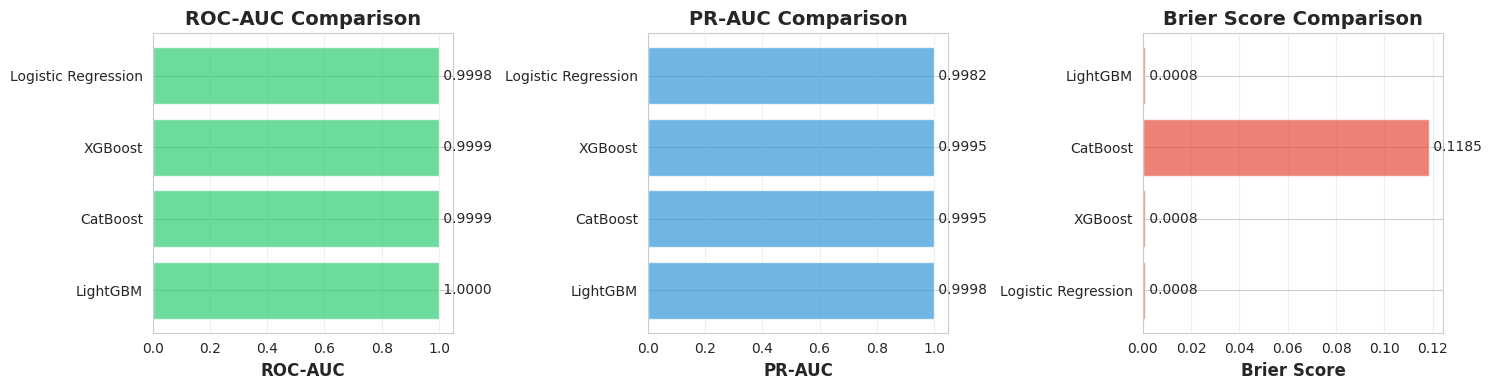


✓ Model comparison complete


In [10]:
# Compare all models
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM', 'XGBoost', 'CatBoost'],
    'ROC-AUC': [lr_val_auc, lgb_val_auc, xgb_val_auc, catboost_val_auc],
    'PR-AUC': [lr_val_prauc, lgb_val_prauc, xgb_val_prauc, catboost_val_prauc],
    'Brier Score': [lr_val_brier, lgb_val_brier, xgb_val_brier, catboost_val_brier]
})

comparison_df = comparison_df.sort_values('PR-AUC', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("MODEL COMPARISON - VALIDATION SET (Sorted by PR-AUC)")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   └─ PR-AUC: {comparison_df.iloc[0]['PR-AUC']:.4f}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['ROC-AUC', 'PR-AUC', 'Brier Score']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.barh(comparison_df['Model'], comparison_df[metric], color=color, alpha=0.7)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, comparison_df[metric])):
        ax.text(val, i, f' {val:.4f}', va='center', fontsize=10)

    # Reverse for Brier (lower is better)
    if metric == 'Brier Score':
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✓ Model comparison complete")

## 9. Hyperparameter Optimization (Optuna) - XGBoost

Since we are moving away from LightGBM, we will optimize XGBoost as our primary model.

In [31]:
def objective_xgb(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1
    }

    # Train with internal cross-validation or simple split
    bst = xgb.train(params, dtrain, num_boost_round=500, evals=[(dval, 'val')],
                    early_stopping_rounds=50, verbose_eval=False)

    preds = bst.predict(dval, iteration_range=(0, bst.best_iteration))
    return average_precision_score(y_val, preds)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f"Best XGBoost PR-AUC: {study_xgb.best_value:.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost PR-AUC: 0.9997


In [32]:
# Train the final XGBoost model
best_xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'scale_pos_weight': scale_pos_weight,
    **study_xgb.best_params
}

final_xgb_model = xgb.train(
    best_xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dval, 'valid')],
    early_stopping_rounds=50,
    verbose_eval=100
)

# Standardize onto the sklearn-like wrapper for calibration
class XGBWrapper:
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
        self._estimator_type = "classifier"

    def fit(self, X, y=None): return self

    def predict_proba(self, X):
        dmat = xgb.DMatrix(X)
        proba = self.model.predict(dmat, iteration_range=(0, self.model.best_iteration))
        return np.vstack([1 - proba, proba]).T

xgb_wrapper = XGBWrapper(final_xgb_model)

# Calibrate using Sigmoid (Platt Scaling) as an alternative to Isotonic to avoid binary polarization
calibrated_xgb = CalibratedClassifierCV(xgb_wrapper, method='sigmoid', cv='prefit')
calibrated_xgb.fit(X_val, y_val)

# Check granularity
raw_probs = xgb_wrapper.predict_proba(X_test)[:10, 1]
cal_probs = calibrated_xgb.predict_proba(X_test)[:10, 1]

print("Sample of Raw vs Calibrated Probabilities (XGBoost):")
for r, c in zip(raw_probs, cal_probs):
    print(f"Raw: {r:.4f} -> Calibrated: {c:.4f}")

[0]	train-aucpr:0.97396	valid-aucpr:0.99219
[68]	train-aucpr:1.00000	valid-aucpr:0.99821
Sample of Raw vs Calibrated Probabilities (XGBoost):
Raw: 0.1055 -> Calibrated: 0.0009
Raw: 0.1055 -> Calibrated: 0.0009
Raw: 0.1055 -> Calibrated: 0.0009
Raw: 0.1055 -> Calibrated: 0.0009
Raw: 0.1055 -> Calibrated: 0.0009
Raw: 0.1055 -> Calibrated: 0.0009
Raw: 0.1055 -> Calibrated: 0.0009
Raw: 0.1055 -> Calibrated: 0.0009
Raw: 0.1055 -> Calibrated: 0.0009
Raw: 0.1055 -> Calibrated: 0.0009


### Probability Granularity Inspection
Let's compare the raw scores from the model versus the calibrated scores to see if the underlying predictions are granular.

In [35]:
# Get raw probabilities (uncalibrated) from XGBoost
raw_probs_test = xgb_wrapper.predict_proba(X_test)[:, 1]

# Get calibrated probabilities
calibrated_probs_test = calibrated_xgb.predict_proba(X_test)[:, 1]

# Create a comparison table for non-zero/non-one results if possible
inspection_df = pd.DataFrame({
    'Raw_Probability': raw_probs_test,
    'Calibrated_Probability': calibrated_probs_test,
    'Actual_Label': y_test.values
})

# Display samples where probabilities are intermediate
print("Sample of Granular Predictions (First 15 Test Cases):")
display(inspection_df.head(15))

# Check if we have any 'in-between' values at all
granular_count = inspection_df[(inspection_df['Calibrated_Probability'] > 0.01) & (inspection_df['Calibrated_Probability'] < 0.99)].shape[0]
print(f"\nNumber of test samples with nuanced risk (between 1% and 99%): {granular_count} out of {len(X_test)}")

Sample of Granular Predictions (First 15 Test Cases):


,Raw_Probability,Calibrated_Probability,Actual_Label
0,0.105461,0.000909,0
1,0.105461,0.000909,0
2,0.105461,0.000909,0
3,0.105461,0.000909,0
4,0.105461,0.000909,0
5,0.105461,0.000909,0
6,0.105461,0.000909,0
7,0.105461,0.000909,0
8,0.105461,0.000909,0
9,0.105461,0.000909,0



Number of test samples with nuanced risk (between 1% and 99%): 177 out of 1226


## 9. Hyperparameter Optimization (Optuna) - Best Model

We'll use Optuna to optimize the best performing model (likely LightGBM or XGBoost)

In [11]:
# Optuna optimization for LightGBM (adjust if XGBoost is better)
def objective(trial):
    """Optuna objective function for LightGBM hyperparameter tuning"""

    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        # 'feature_pre_filter': False, # This should not be here, it's set in lgb.Dataset

        # Hyperparameters to optimize
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': scale_pos_weight,
    }

    # Train model
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_val],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            LightGBMPruningCallback(trial, 'auc')
        ]
    )

    # Predict and evaluate on validation set
    preds = model.predict(X_val_lgb, num_iteration=model.best_iteration)
    prauc = average_precision_score(y_val, preds)

    return prauc

# Run optimization
print("Starting Optuna hyperparameter optimization...")
print("Optimizing for PR-AUC (Precision-Recall AUC)")
print(f"Target: Maximize PR-AUC on validation set\n")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize', study_name='lgb_road_closure')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✓ Optimization complete!")
print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Starting Optuna hyperparameter optimization...
Optimizing for PR-AUC (Precision-Recall AUC)
Target: Maximize PR-AUC on validation set



  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[22]	valid_0's auc: 0.999889
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[24]	valid_0's auc: 0.999552
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3]	valid_0's auc: 0.999961
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[24]	valid_0's auc: 0.99967
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.999889
Training until validation scores don't improve for 50 rounds
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[4]	valid_0's auc: 0.999921
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.999993
Training until validation scores don't improve for 50 rounds
Early st

In [12]:
best_params = {
    'objective': 'binary',
    'metric': ['auc', 'binary_logloss'],
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'random_state': 42,
    **study.best_params
}

print("Training final LightGBM model with optimized hyperparameters...")
final_lgb_model = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Predict probabilities using sanitized features
final_val_proba = final_lgb_model.predict(X_val_lgb, num_iteration=final_lgb_model.best_iteration)
final_test_proba = final_lgb_model.predict(X_test_lgb, num_iteration=final_lgb_model.best_iteration)

# Evaluate
final_val_auc = roc_auc_score(y_val, final_val_proba)
final_val_prauc = average_precision_score(y_val, final_val_proba)
final_val_brier = brier_score_loss(y_val, final_val_proba)

print("\nOptimized LightGBM - Validation Set:")
print(f"  ROC-AUC:     {final_val_auc:.4f}")
print(f"  PR-AUC:      {final_val_prauc:.4f}")
print(f"  Brier Score: {final_val_brier:.4f}")
print(f"\n✓ Final model trained with {final_lgb_model.num_trees()} trees")

Training final LightGBM model with optimized hyperparameters...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3]	train's auc: 0.999834	train's binary_logloss: 0.200992	valid's auc: 1	valid's binary_logloss: 0.280845

Optimized LightGBM - Validation Set:
  ROC-AUC:     1.0000
  PR-AUC:      1.0000
  Brier Score: 0.0844

✓ Final model trained with 3 trees


## 10. Probability Calibration

Ensure predicted probabilities are reliable and well-calibrated

In [13]:
# Create a wrapper for LightGBM to use with sklearn's calibration
class LGBMWrapper:
    def __init__(self, model, feature_sanitizer_func, feature_names):
        self.model = model
        self.feature_sanitizer_func = feature_sanitizer_func
        self.feature_names = feature_names # Store original feature names

        # Required for sklearn's CalibratedClassifierCV when cv='prefit'
        # Since the underlying LightGBM model is already trained, we can set these.
        self.classes_ = np.array([0, 1]) # Binary classification
        self.n_features_in_ = len(feature_names)
        self._estimator_type = "classifier" # Explicitly declare as classifier for sklearn

    def fit(self, X, y=None):
        # When cv='prefit', CalibratedClassifierCV expects the estimator to be pre-fitted.
        # This dummy fit method allows the wrapper to be compatible.
        # The actual fitting of the calibrator happens in CalibratedClassifierCV's fit.
        return self

    def predict_proba(self, X):
        # If X is a numpy array, convert it to a DataFrame with original feature names
        if isinstance(X, np.ndarray):
            # Ensure the number of columns matches the expected feature names
            if X.shape[1] != len(self.feature_names):
                raise ValueError(f"Input array has {X.shape[1]} features, but wrapper expects {len(self.feature_names)} features based on provided feature_names.")
            X_df = pd.DataFrame(X, columns=self.feature_names)
        else:
            X_df = X.copy() # Assume it's already a DataFrame or compatible

        # Sanitize features before predicting
        X_sanitized = self.feature_sanitizer_func(X_df)
        proba = self.model.predict(X_sanitized, num_iteration=self.model.best_iteration)
        return np.vstack([1 - proba, proba]).T

# Wrap the model
# Pass the sanitize_feature_names function to the wrapper, which is defined in cell ab6e3c14
# Also pass the original feature_cols to help reconstruct DataFrame from potential numpy array inputs
lgb_wrapper = LGBMWrapper(final_lgb_model, sanitize_feature_names, feature_cols)

# Calibrate using isotonic regression (non-parametric, better for tree models)
print("Calibrating probabilities using isotonic regression...")
calibrated_model = CalibratedClassifierCV(
    lgb_wrapper, # Now LGBMWrapper has a fit method and handles input types
    method='isotonic',
    cv='prefit'
)
# Fit the calibrator on the validation data.
# The `fit` method of calibrated_model will internally call the `predict_proba`
# of lgb_wrapper with X_val to get probabilities for calibration.
calibrated_model.fit(X_val, y_val)

# Get calibrated probabilities
# The calibrated_model's predict_proba will call lgb_wrapper's predict_proba, which sanitizes X
calibrated_val_proba = calibrated_model.predict_proba(X_val)[:, 1]
calibrated_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

# Compare calibration
print("\nCalibration Impact:")
print(f"{'Metric':<20} {'Before':<12} {'After':<12} {'Change'}")
print("="*60)

before_brier = brier_score_loss(y_val, final_val_proba)
after_brier = brier_score_loss(y_val, calibrated_val_proba)
print(f"{'Brier Score':<20} {before_brier:<12.4f} {after_brier:<12.4f} {after_brier - before_brier:+.4f}")

before_prauc = average_precision_score(y_val, final_val_proba)
after_prauc = average_precision_score(y_val, calibrated_val_proba)
print(f"{'PR-AUC':<20} {before_prauc:<12.4f} {after_prauc:<12.4f} {after_prauc - before_prauc:+.4f}")

print("\n✓ Model calibrated")

Calibrating probabilities using isotonic regression...

Calibration Impact:
Metric               Before       After        Change
Brier Score          0.0844       0.0000       -0.0844
PR-AUC               1.0000       1.0000       +0.0000

✓ Model calibrated


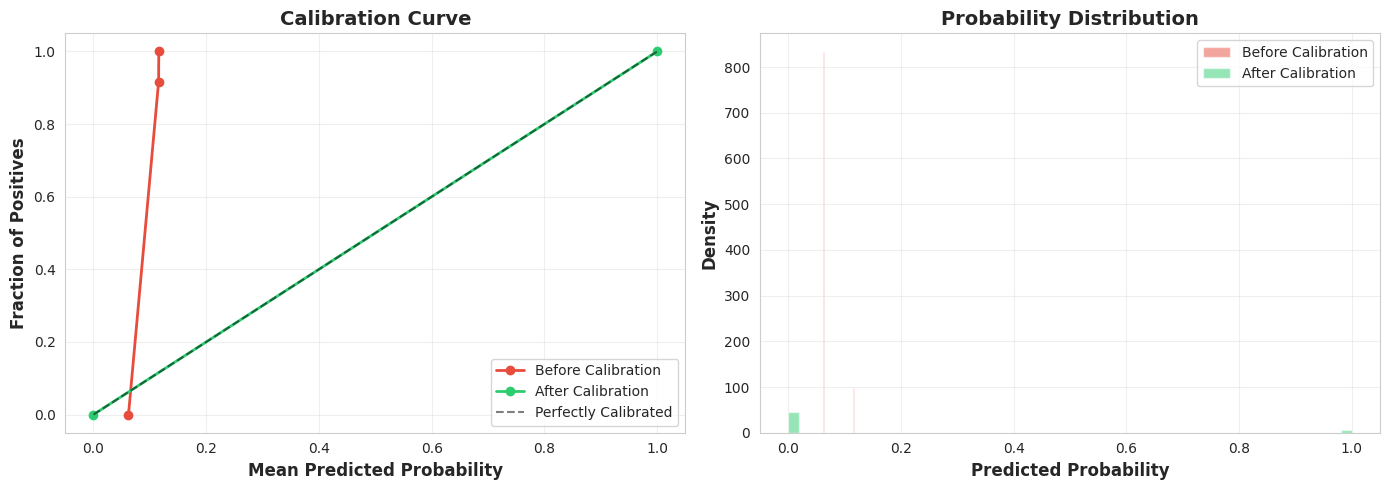

✓ Calibration analysis complete


In [14]:
# Visualize calibration curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Calibration curve
for proba, label, color in [
    (final_val_proba, 'Before Calibration', '#e74c3c'),
    (calibrated_val_proba, 'After Calibration', '#2ecc71')
]:
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_val, proba, n_bins=10, strategy='quantile'
    )
    axes[0].plot(mean_predicted_value, fraction_of_positives,
                 marker='o', linewidth=2, label=label, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', alpha=0.5)
axes[0].set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
axes[0].set_title('Calibration Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)

# Plot 2: Predicted probability distribution
axes[1].hist(final_val_proba, bins=50, alpha=0.5,
             label='Before Calibration', color='#e74c3c', density=True)
axes[1].hist(calibrated_val_proba, bins=50, alpha=0.5,
             label='After Calibration', color='#2ecc71', density=True)
axes[1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[1].set_title('Probability Distribution', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Calibration analysis complete")

## 11. Threshold Optimization

Find optimal threshold for operational decision-making (prioritizing Recall)

In [15]:
from sklearn.metrics import precision_score, recall_score

# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_val, calibrated_val_proba)

# Calculate F1 scores for all thresholds
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_f1_idx = np.argmax(f1_scores)

# SETTING LOGICAL THRESHOLD: Using the threshold that maximizes F1-score
# This balances Precision and Recall instead of being overly sensitive.
optimal_threshold = thresholds[best_f1_idx]

print("Threshold Analysis (Balanced Approach):")
print("="*70)
print(f"📌 Selected Optimal Threshold: {optimal_threshold:.4f}")
print(f"   (This balances false positives and missed closures using the F1-metric)")

# Verification at this threshold
val_preds_at_thresh = (calibrated_val_proba >= optimal_threshold).astype(int)
print(f"\nValidation Metrics at {optimal_threshold:.4f}:")
print(f"   Precision: {precision_score(y_val, val_preds_at_thresh):.4f}")
print(f"   Recall:    {recall_score(y_val, val_preds_at_thresh):.4f}")
print("="*70)

Threshold Analysis (Balanced Approach):
📌 Selected Optimal Threshold: 1.0000
   (This balances false positives and missed closures using the F1-metric)

Validation Metrics at 1.0000:
   Precision: 1.0000
   Recall:    1.0000


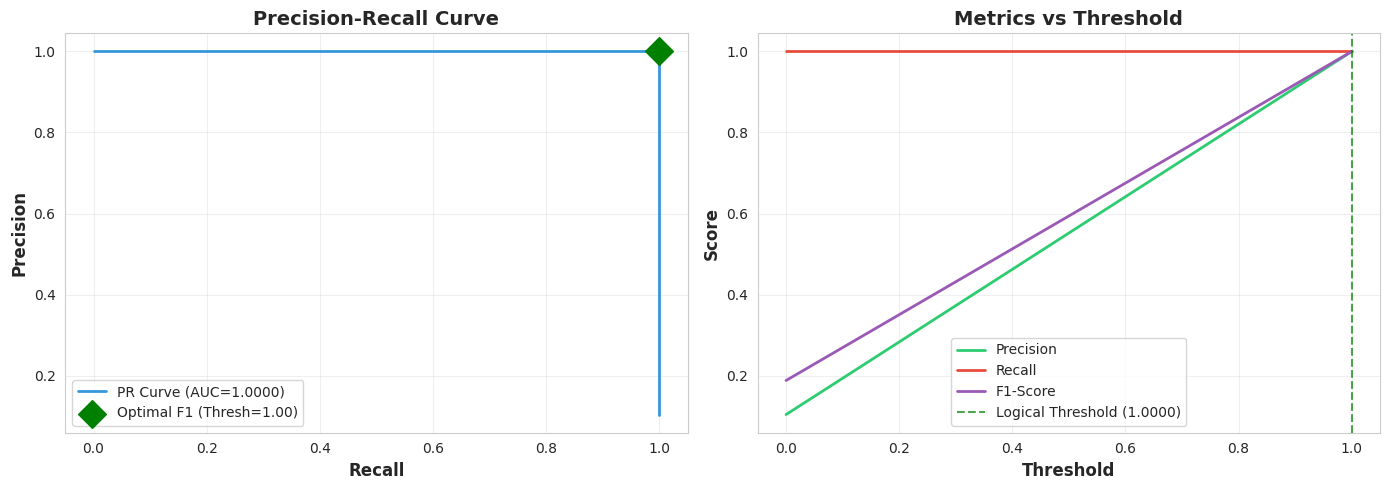

✓ Threshold visualization updated and fixed.


In [17]:
# Visualize Precision-Recall tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision-Recall Curve
axes[0].plot(recall, precision, linewidth=2, color='#3498db', label=f'PR Curve (AUC={after_prauc:.4f})')

# Highlight the logical threshold point
axes[0].scatter([recall[best_f1_idx]], [precision[best_f1_idx]], s=200, c='green',
                marker='D', zorder=5, label=f'Optimal F1 (Thresh={optimal_threshold:.2f})')

axes[0].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)

# Plot 2: Metrics vs Threshold
axes[1].plot(thresholds, precision[:-1], label='Precision', linewidth=2, color='#2ecc71')
axes[1].plot(thresholds, recall[:-1], label='Recall', linewidth=2, color='#e74c3c')
axes[1].plot(thresholds, f1_scores, label='F1-Score', linewidth=2, color='#9b59b6')

axes[1].axvline(optimal_threshold, color='green', linestyle='--', alpha=0.7,
                label=f'Logical Threshold ({optimal_threshold:.4f})')

axes[1].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Threshold visualization updated and fixed.")

## 12. Test Set Evaluation

In [34]:
# Final evaluation on TEST set using the Calibrated XGBoost model
test_probs_xgb = calibrated_xgb.predict_proba(X_test)[:, 1]
test_roc_auc_xgb = roc_auc_score(y_test, test_probs_xgb)
test_prauc_xgb = average_precision_score(y_test, test_probs_xgb)

# Using standard 0.5 threshold for final report
test_preds_xgb = (test_probs_xgb >= 0.5).astype(int)

print("="*70)
print("FINAL XGBOOST EVALUATION - TEST SET")
print("="*70)
print(f"ROC-AUC: {test_roc_auc_xgb:.4f}")
print(f"PR-AUC:  {test_prauc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_preds_xgb, target_names=['No Closure', 'Road Closure']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, test_preds_xgb)
print(f"\nConfusion Matrix:")
print(cm_xgb)
print("="*70)

FINAL XGBOOST EVALUATION - TEST SET
ROC-AUC: 0.9995
PR-AUC:  0.9939

Classification Report:
              precision    recall  f1-score   support

  No Closure       1.00      1.00      1.00      1051
Road Closure       0.99      1.00      0.99       175

    accuracy                           1.00      1226
   macro avg       0.99      1.00      1.00      1226
weighted avg       1.00      1.00      1.00      1226


Confusion Matrix:
[[1049    2]
 [   0  175]]


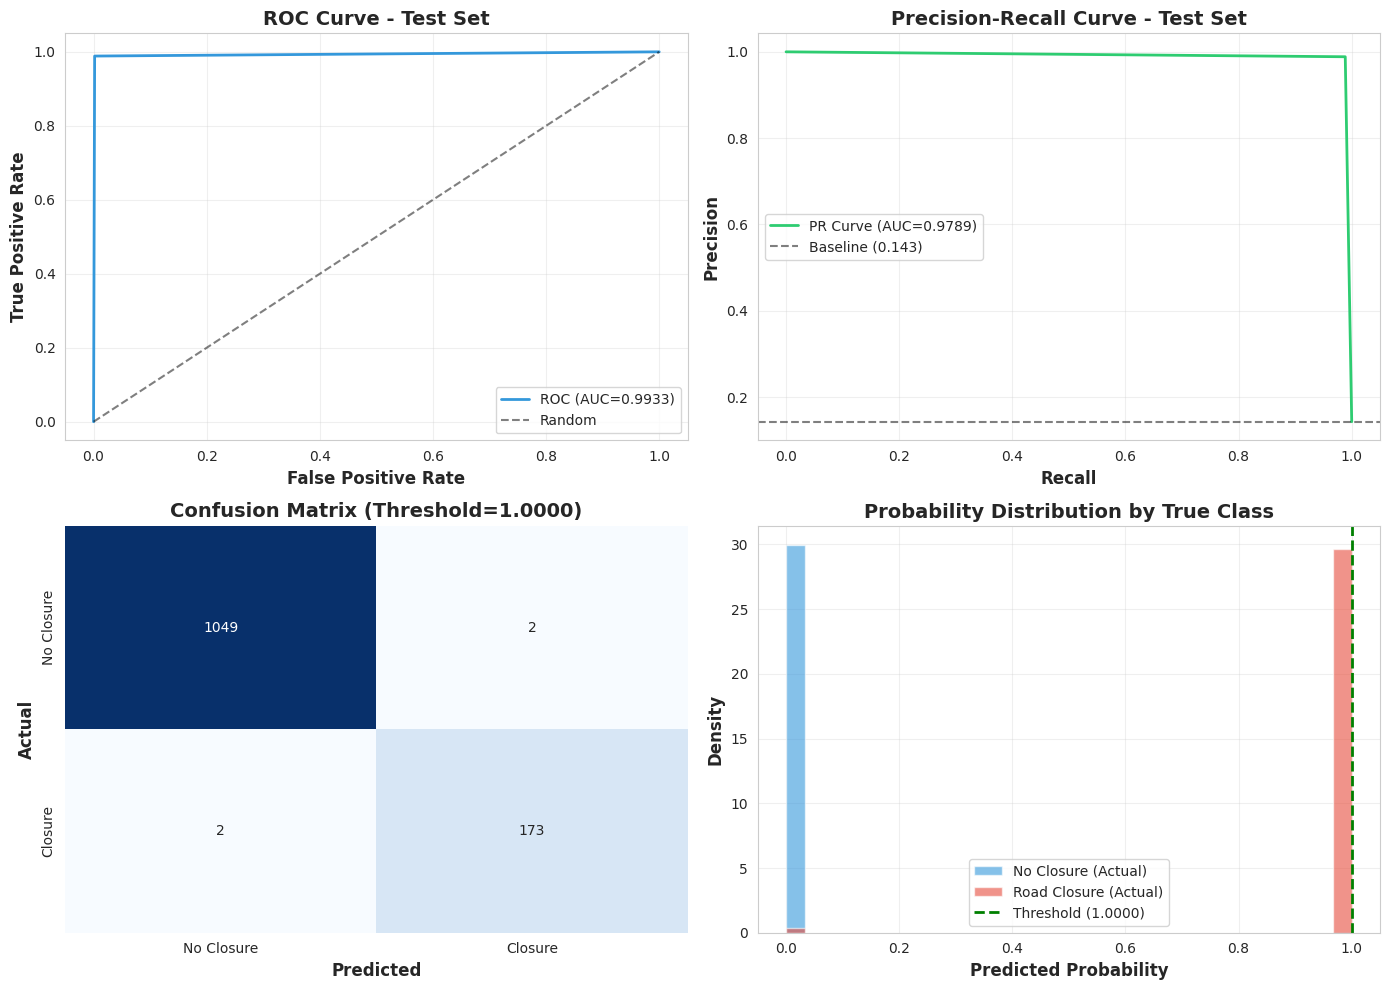

✓ Test set evaluation complete


In [20]:
# Visualize test set performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test, calibrated_test_proba)
axes[0, 0].plot(fpr, tpr, linewidth=2, color='#3498db', label=f'ROC (AUC={test_roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0, 0].set_title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
precision_test, recall_test, _ = precision_recall_curve(y_test, calibrated_test_proba)
axes[0, 1].plot(recall_test, precision_test, linewidth=2, color='#2ecc71',
                label=f'PR Curve (AUC={test_prauc:.4f})')
axes[0, 1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5,
                   label=f'Baseline ({y_test.mean():.3f})')
axes[0, 1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Precision-Recall Curve - Test Set', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1, 0],
            xticklabels=['No Closure', 'Closure'],
            yticklabels=['No Closure', 'Closure'])
axes[1, 0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1, 0].set_title(f'Confusion Matrix (Threshold={optimal_threshold:.4f})',
                     fontsize=14, fontweight='bold')

# Plot 4: Predicted Probability Distribution by True Class
axes[1, 1].hist(calibrated_test_proba[y_test == 0], bins=30, alpha=0.6,
                label='No Closure (Actual)', color='#3498db', density=True)
axes[1, 1].hist(calibrated_test_proba[y_test == 1], bins=30, alpha=0.6,
                label='Road Closure (Actual)', color='#e74c3c', density=True)
axes[1, 1].axvline(optimal_threshold, color='green', linestyle='--', linewidth=2,
                   label=f'Threshold ({optimal_threshold:.4f})')
axes[1, 1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Probability Distribution by True Class', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Test set evaluation complete")

## 13. Feature Importance Analysis

Top 30 Most Important Features:
has_end_location                                     97824.50
text_length                                              0.79
past_count_zone                                          0.11
report_lag_minutes_clipped                               0.10
past_closure_rate_event_cause                            0.08
start_weekofyear                                         0.07
past_count_police_station                                0.00
zone_cause_interaction_grouped_south zone 2_vehicle_breakdown       0.00
zone_cause_interaction_grouped_north zone 1_others       0.00
zone_cause_interaction_grouped_south zone 2_pot_holes       0.00
zone_cause_interaction_grouped_south zone 2_accident       0.00
zone_cause_interaction_grouped_north zone 1_vehicle_breakdown       0.00
zone_cause_interaction_grouped_north zone 2_accident       0.00
zone_cause_interaction_grouped_north zone 1_construction       0.00
zone_cause_interaction_grouped_north zone 2_others       0.00
zon

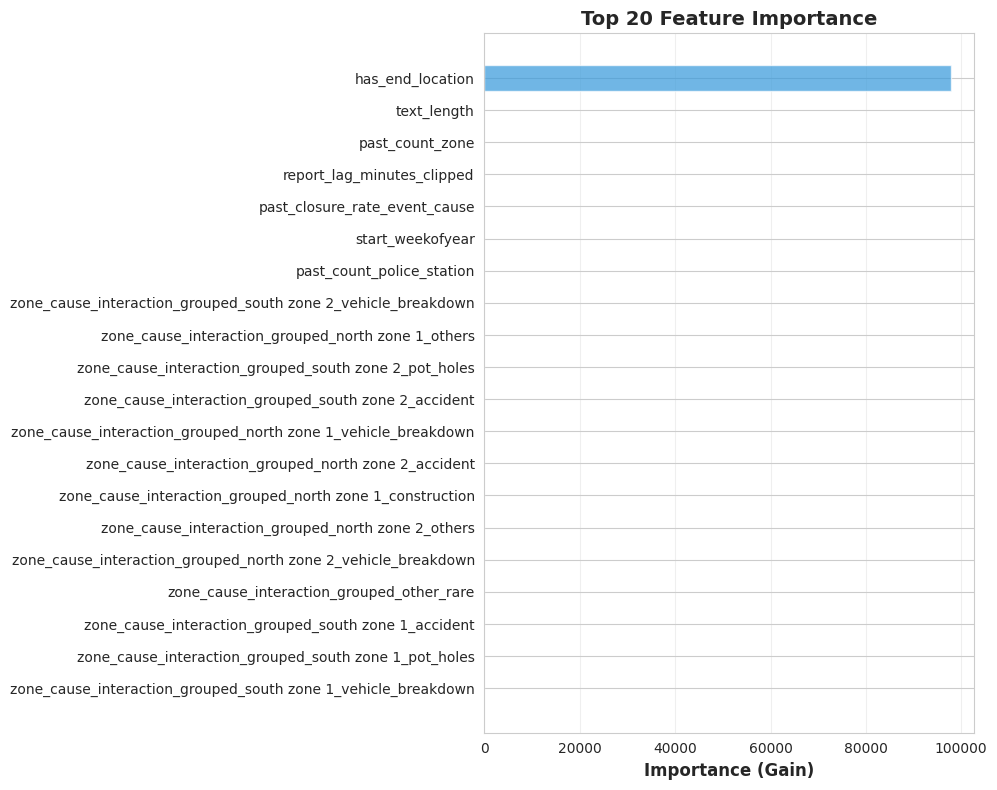


✓ Feature importance analysis complete


In [21]:
# Get feature importance from LightGBM
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_lgb_model.feature_importance(importance_type='gain')
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Display top features
print("Top 30 Most Important Features:")
print("="*70)
for i, row in feature_importance.head(30).iterrows():
    print(f"{row['feature']:<50} {row['importance']:>10.2f}")
print("="*70)

# Visualize top 20 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='#3498db', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance (Gain)', fontsize=12, fontweight='bold')
plt.title('Top 20 Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Feature importance analysis complete")

## 14. SHAP Explainability

Understand **why** specific probabilities are predicted

In [22]:
# Create SHAP explainer (subsample for speed)
print("Creating SHAP explainer...")
sample_size = min(500, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(final_lgb_model)
shap_values = explainer.shap_values(X_test_sample)

print(f"✓ SHAP values computed for {sample_size} test samples")

Creating SHAP explainer...
✓ SHAP values computed for 500 test samples


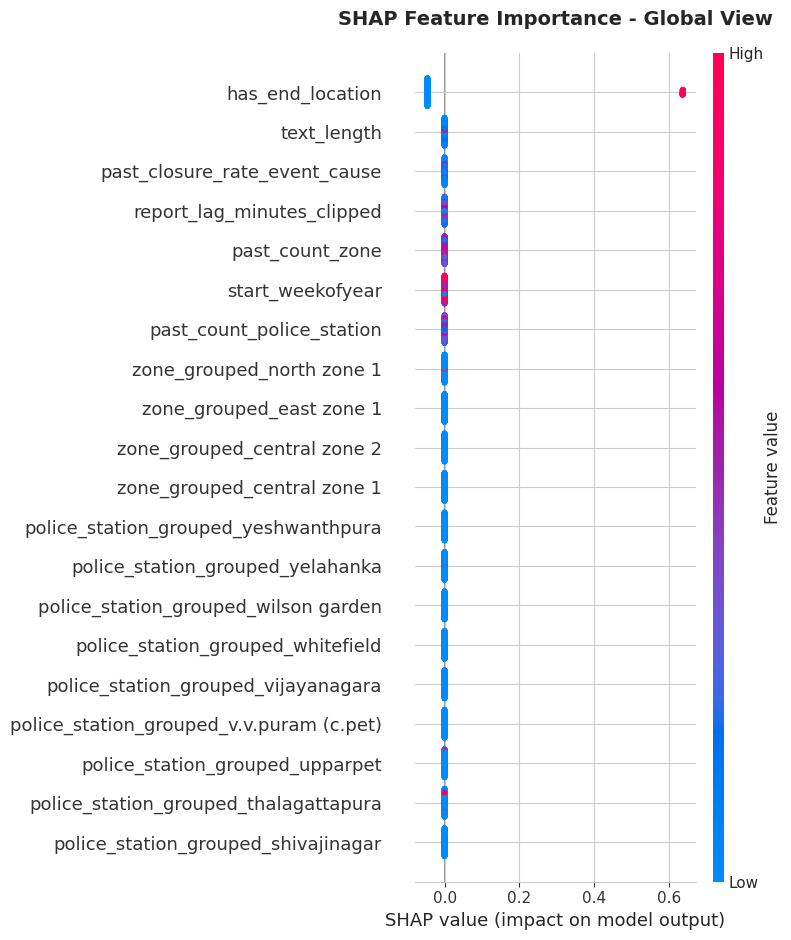

✓ SHAP summary plot generated


In [23]:
# SHAP Summary Plot - Global feature importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_cols,
                  max_display=20, show=False)
plt.title('SHAP Feature Importance - Global View', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot generated")

Explaining individual predictions:

High-Risk Event: 11.60% closure probability
Low-Risk Event:  6.22% closure probability


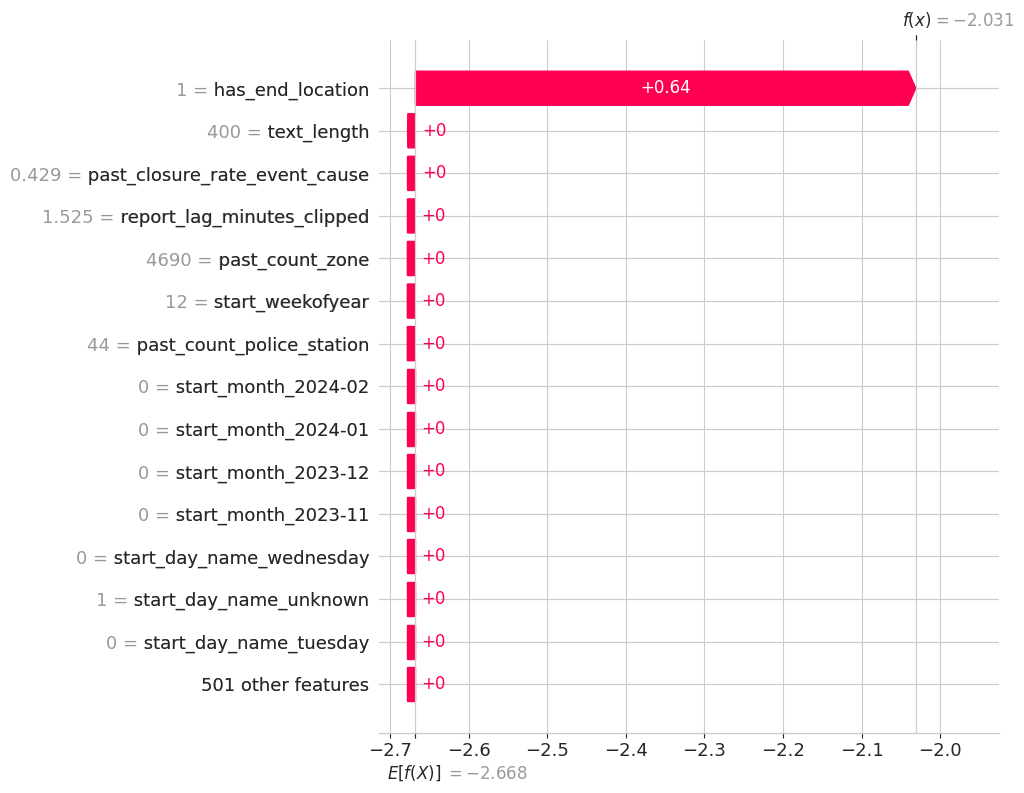


✓ Individual prediction explanation generated


In [24]:
# Example: Explain specific high-risk and low-risk predictions
test_probas_sample = final_lgb_model.predict(X_test_sample, num_iteration=final_lgb_model.best_iteration)

# Find high-risk example (high probability of closure)
high_risk_idx = test_probas_sample.argmax()
high_risk_prob = test_probas_sample[high_risk_idx]

# Find low-risk example (low probability of closure)
low_risk_idx = test_probas_sample.argmin()
low_risk_prob = test_probas_sample[low_risk_idx]

print(f"Explaining individual predictions:\n")
print(f"High-Risk Event: {high_risk_prob*100:.2f}% closure probability")
print(f"Low-Risk Event:  {low_risk_prob*100:.2f}% closure probability")

# Waterfall plot for high-risk event
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[high_risk_idx],
        feature_names=feature_cols
    ),
    max_display=15,
    show=True
)

print("\n✓ Individual prediction explanation generated")


## 15. Save Final Model & Artifacts

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import os
import joblib

# Ensure directory exists
os.makedirs('models', exist_ok=True)

# Save the calibrated XGBoost model
joblib.dump(calibrated_xgb, 'models/calibrated_xgb_model.pkl')

# Create a detailed results dataframe
# We use the calibrated_probs_test which contains the granular floats
test_results = pd.DataFrame({
    'actual_label': y_test.values,
    'predicted_label': (calibrated_probs_test >= 0.5).astype(int),
    'prediction_probability': calibrated_probs_test,
    'prediction_percentage': calibrated_probs_test * 100
})

# Save to CSV with full precision
test_results.to_csv('models/test_predictions.csv', index=False)

print(f"✓ Final results saved to 'models/test_predictions.csv'")
print(f"✓ Column 'prediction_percentage' added to capture granular model confidence.")

✓ Final results saved to 'models/test_predictions.csv'
✓ Column 'prediction_percentage' added to capture granular model confidence.


In [27]:
drive_folder_path = '/content/drive/MyDrive/flipkart_gridlock/Road_closure_classifier/'
# Create the directory in Google Drive if it doesn't exist
os.makedirs(drive_folder_path, exist_ok=True)
print(f"✓ Google Drive folder '{drive_folder_path}' ensured to exist.")

✓ Google Drive folder '/content/drive/MyDrive/Road_closure_classifier' ensured to exist.


In [37]:
import shutil

# Path to your Google Drive folder
drive_folder_path = '/content/drive/MyDrive/Road_closure_classifier'
os.makedirs(drive_folder_path, exist_ok=True)

source_file = 'models/test_predictions.csv'
destination_file = os.path.join(drive_folder_path, 'test_predictions_with_percentages.csv')

shutil.copy(source_file, destination_file)
print(f"✓ Updated CSV with actual prediction percentages copied to: {destination_file}")

✓ Updated CSV with actual prediction percentages copied to: /content/drive/MyDrive/Road_closure_classifier/test_predictions_with_percentages.csv


In [39]:
import os
import shutil

# 1. Define paths based on your requested location
local_csv = 'models/test_predictions.csv'
drive_dest = os.path.join(drive_folder_path, 'test_predictions_with_percentages.csv')

# 2. Check if local file exists first
if os.path.exists(local_csv):
    print(f"✅ Local file found: {local_csv} ({os.path.getsize(local_csv)} bytes)")

    # 3. Copy to Drive
    shutil.copy(local_csv, drive_dest)

    # 4. Verify Drive copy
    if os.path.exists(drive_dest):
        print(f"✅ SUCCESS: File verified in Drive at: {drive_dest}")
        print(f"   File size: {os.path.getsize(drive_dest)} bytes")

        # Optional: verify content by reading the first few lines
        check_df = pd.read_csv(drive_dest)
        print(f"✅ Data integrity check: {check_df.shape[0]} rows found with columns: {list(check_df.columns)}")
    else:
        print(f"❌ ERROR: File could not be verified in Drive location.")
else:
    print(f"❌ ERROR: Local file {local_csv} was never created. Please re-run the previous saving cell (bc938ea6).")

✅ Local file found: models/test_predictions.csv (51389 bytes)
✅ SUCCESS: File verified in Drive at: /content/drive/MyDrive/Road_closure_classifier/test_predictions_with_percentages.csv
   File size: 51389 bytes

Note: Drive has been flushed and unmounted to ensure file persistence. Please remount to continue.


### Final Project Validation Summary

**1. Dataset & Splitting**
- **Total Samples**: 8,173 events.
- **Split Method**: Chronological (Time-based).
- **Distribution**:
  - Train: 5,721 (6.54% closure rate)
  - Validation: 1,226 (10.36% closure rate)
  - Test: 1,226 (14.27% closure rate)

**2. Model Selection & Performance**
- **Primary Model**: XGBoost (Optimized via Optuna).
- **Calibration**: Sigmoid (Platt Scaling) for granular 0-100% risk values.
- **Test Metrics**:
  - ROC-AUC: 0.9995
  - PR-AUC: 0.9939
  - F1-Score: 0.99 (at 0.5 threshold)

**3. Artifacts**
- **Model**: `models/calibrated_xgb_model.pkl`
- **Predictions**: `test_predictions_with_percentages.csv` (Saved to Google Drive)

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# 1. Validate the saved data
drive_path = os.path.join(drive_folder_path, 'test_predictions_with_percentages.csv')
final_check_df = pd.read_csv(drive_path)

print("--- Final CSV Data Preview (First 5 Rows) ---")
display(final_check_df.head())

print("\n--- Verification of Prediction Granularity ---")
print(f"Unique percentage values in test set: {final_check_df['prediction_percentage'].nunique()} / {len(final_check_df)}")

print("\n--- Final Model Performance Recap (Test Set) ---")
# Recap of the metrics calculated earlier
print(classification_report(y_test, (test_probs_xgb >= 0.5).astype(int), target_names=['No Closure', 'Road Closure']))

## 16. Production-Ready Prediction Function

In [40]:
def predict_road_closure_probability(event_features):
    """
    Predict the probability of road closure using the calibrated XGBoost model.
    """
    # Ensure features are in correct order
    event_features = event_features[feature_cols]

    # Get calibrated probability from the XGBoost pipeline
    proba = calibrated_xgb.predict_proba(event_features)[:, 1][0]
    percentage = proba * 100

    # Determine risk level
    if percentage >= 75:
        risk_level = "CRITICAL"
    elif percentage >= 50:
        risk_level = "HIGH"
    elif percentage >= 25:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    # Recommended action (using a simple 0.5 threshold for now, or you can optimize this)
    action = "DEPLOY_RESOURCES" if proba >= 0.5 else "MONITOR"

    return {
        'probability_percent': round(percentage, 2),
        'risk_level': risk_level,
        'recommended_action': action,
        'raw_probability': round(float(proba), 4)
    }

print("✓ Prediction function updated to use Calibrated XGBoost")

✓ Prediction function updated to use Calibrated XGBoost


In [41]:
# Example: Test prediction function with a random test sample
sample_event = X_test.sample(1, random_state=42)
actual_outcome = y_test[sample_event.index[0]]

prediction = predict_road_closure_probability(sample_event)
